In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [3]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
data.drop(columns=['API_UserName','observations','dayofweek','is_weekend','day','month'], inplace=True)
# Ensure the 'date' column is in datetime format
data['date'] = pd.to_datetime(data['date'])
#data = data[data['indicator'] == '146.71.50.198']
data.tail(300)


,date,indicator,seen
22011,2025-04-20,23.26.221.24,0
22012,2025-04-20,23.26.221.26,0
22013,2025-04-20,46.246.8.46,0
22014,2025-04-20,46.246.8.56,0
22015,2025-04-20,46.246.8.96,0
...,...,...,...
22306,2025-04-21,107.180.119.251,0
22307,2025-04-21,190.92.174.36,0
22308,2025-04-21,192.124.249.112,0
22309,2025-04-21,66.132.159.247,0


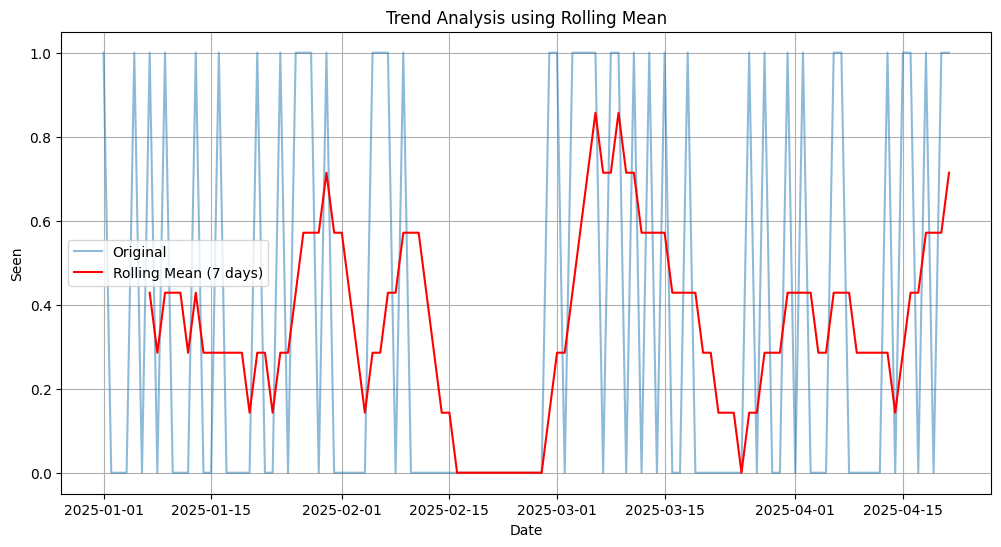

In [293]:
# Calculate the rolling mean for the 'seen' column
data['rolling_mean'] = data['seen'].rolling(window=7).mean()

# Plot the original 'seen' values and the rolling mean
plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['seen'], label='Original', alpha=0.5)
plt.plot(data['date'], data['rolling_mean'], label='Rolling Mean (7 days)', color='red')
plt.title('Trend Analysis using Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Seen')
plt.legend()
plt.grid()
plt.show()

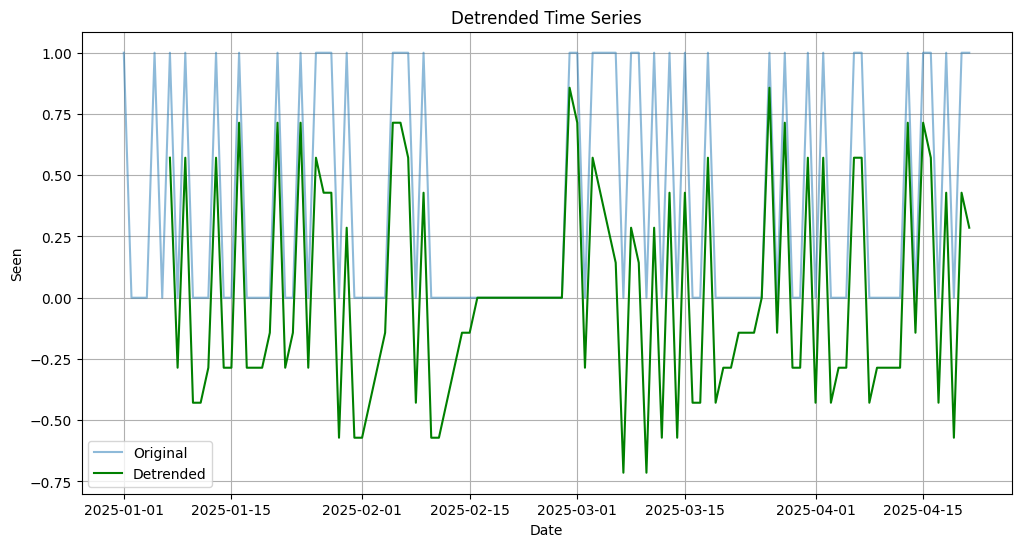

In [294]:
# Detrend the 'seen' column using differencing
data['detrended_seen'] = data['seen'] - data['rolling_mean']

# Plot the original 'seen' values and the detrended values
plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['seen'], label='Original', alpha=0.5)
plt.plot(data['date'], data['detrended_seen'], label='Detrended', color='green')
plt.title('Detrended Time Series')
plt.xlabel('Date')
plt.ylabel('Seen')
plt.legend()
plt.grid()
plt.show()

ADF Statistic: -5.329373782793633
p-value: 4.758439015272364e-06
Critical Values:
   1%: -3.4968181663902103
   5%: -2.8906107514600103
   10%: -2.5822770483285953
The data is stationary.


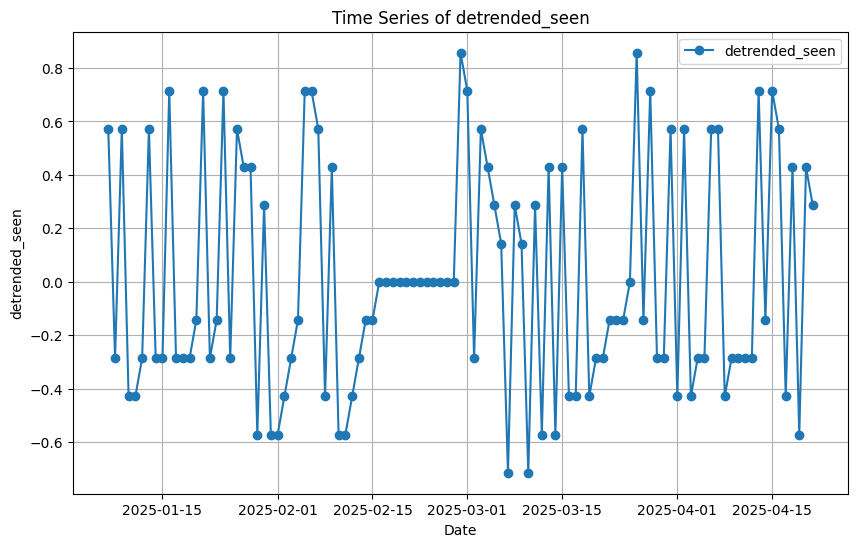

In [295]:
# Check stationarity using Augmented Dickey-Fuller test
column = 'detrended_seen'  # Replace 'seen' with the desired column name if needed

# Drop rows with NaN or infinite values in the specified column
data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=[column])
def check_stationarity(data, column):
    result = adfuller(data[column])
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    if result[1] <= 0.05:
        print("The data is stationary.")
    else:
        print("The data is not stationary.")

# Apply the function to the specified column
check_stationarity(data, column)

# Plot the specified column over time
plt.figure(figsize=(10, 6))
plt.plot(data['date'], data[column], marker='o', linestyle='-', label=column)
plt.title(f'Time Series of {column}')
plt.xlabel('Date')
plt.ylabel(column)
plt.legend()
plt.grid()
plt.show()


In [296]:

# Check if the data is stationary
result = adfuller(data[column])
if result[1] > 0.05:  # If p-value > 0.05, the data is not stationary
    print("Data is not stationary. Differencing once...")
    data['differenced'] = data[column].diff()
    
    # Drop NaN or infinite values after differencing
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=['differenced'])
    
    # Check stationarity again after differencing
    result_diff = adfuller(data['differenced'])
    print("After differencing:")
    print("ADF Statistic:", result_diff[0])
    print("p-value:", result_diff[1])
    print("Critical Values:")
    for key, value in result_diff[4].items():
        print(f"   {key}: {value}")
    if result_diff[1] <= 0.05:
        print("The differenced data is stationary.")
    else:
        print("The differenced data is still not stationary.")
    
    # Plot the differenced data
    plt.figure(figsize=(10, 6))
    plt.plot(data['date'], data['differenced'], marker='o', linestyle='-', label='Differenced Data')
    plt.title('Differenced Time Series')
    plt.xlabel('Date')
    plt.ylabel('Differenced Values')
    plt.legend()
    plt.grid()
    plt.show()
else:
    print("Data is already stationary.")

Data is already stationary.


In [297]:
data.isna().sum()

date              0
indicator         0
seen              0
rolling_mean      0
detrended_seen    0
dtype: int64

In [298]:
def days_since_last_seen_all(data):
    # Filter only rows where seen == 1
    seen_data = data[data['seen'] == 1]
    
    # Sort the data by indicator and date in descending order
    seen_data = seen_data.sort_values(by=['indicator', 'date'], ascending=[True, False])
    
    # Keep only the most recent entry for each indicator
    seen_data = seen_data.drop_duplicates(subset=['indicator'], keep='first')
    
    # Calculate the difference in days from today for each entry
    today = pd.to_datetime(datetime.now()).normalize()
    seen_data['days_since_last_seen'] = (today - seen_data['date']).dt.days
    
    # Drop rows with NaN values
    seen_data = seen_data.dropna()
    
    return seen_data[['indicator', 'date', 'seen', 'days_since_last_seen']]

# Compute "days since last seen" for all indicators
days_since_last_seen_all_data = days_since_last_seen_all(data)

# Merge the "days since last seen" back into the main dataset
data = data.merge(
    days_since_last_seen_all_data[['indicator', 'days_since_last_seen']],
    on='indicator',
    how='left'
)

# Fill NaN values with a default (e.g., a large number for unseen indicators)
data['days_since_last_seen'] = data['days_since_last_seen'].interpolate(method='linear')
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data['days_since_last_seen_scaled'] = scaler.fit_transform(data[['days_since_last_seen']])

In [299]:
# Ensure the 'date' column is in datetime format
data['date'] = pd.to_datetime(data['date'])

# Keep the last 7 days in test_data
last_7_days = datetime.now() - timedelta(days=7)
# Normalize today's date (removes the time portion)
today = pd.to_datetime(datetime.now()).normalize()
print(today)

# Filter test_data: only indicators seen today
test_data = data[(data['date'] == today) & (data['seen'] == 1)]
 
test_data = test_data.reset_index(drop=True)

# Use the remaining data for training
data = data[data['date'] < last_7_days]

# Reset the index of the filtered data
data = data.reset_index(drop=True)
# Display the test_data
test_data

2025-04-21 00:00:00


,date,indicator,seen,rolling_mean,detrended_seen,days_since_last_seen,days_since_last_seen_scaled
0,2025-04-21,146.71.50.198,1,0.714286,0.285714,0,0.0


In [300]:
# Define the cutoff date (90 days ago from today)
cutoff_date = datetime.now() - timedelta(days=120)

# Convert the date column to datetime format (if not already)
data['date'] = pd.to_datetime(data['date'])

# Filter the data to include only rows within the last 90 days
filtered_data = data[data['date'] >= cutoff_date]
filtered_data

,date,indicator,seen,rolling_mean,detrended_seen,days_since_last_seen,days_since_last_seen_scaled
0,2025-01-07,146.71.50.198,1,0.428571,0.571429,0,0.0
1,2025-01-08,146.71.50.198,0,0.285714,-0.285714,0,0.0
2,2025-01-09,146.71.50.198,1,0.428571,0.571429,0,0.0
3,2025-01-10,146.71.50.198,0,0.428571,-0.428571,0,0.0
4,2025-01-11,146.71.50.198,0,0.428571,-0.428571,0,0.0
...,...,...,...,...,...,...,...
93,2025-04-10,146.71.50.198,0,0.285714,-0.285714,0,0.0
94,2025-04-11,146.71.50.198,0,0.285714,-0.285714,0,0.0
95,2025-04-12,146.71.50.198,0,0.285714,-0.285714,0,0.0
96,2025-04-13,146.71.50.198,1,0.285714,0.714286,0,0.0


In [301]:
unique_indicators_count = filtered_data['indicator'].nunique()
print(f"Number of unique indicators: {unique_indicators_count}")

Number of unique indicators: 1


In [302]:
target_indicator = '102.129.153.158'
indicator_data = test_data[test_data['indicator'] == target_indicator]
print(indicator_data)


Empty DataFrame
Columns: [date, indicator, seen, rolling_mean, detrended_seen, days_since_last_seen, days_since_last_seen_scaled]
Index: []


In [303]:
indicator_data = data[data['indicator'] == '102.129.153.158']
seen_counts = indicator_data['seen'].value_counts()
print(seen_counts)



Series([], Name: count, dtype: int64)


In [304]:
# Compute per-indicator rolling 7-day reappearance probability
rolling_prob_list = []

# Process each indicator individually
for indicator, group in filtered_data.groupby('indicator'):
    group = group.sort_values('date').reset_index(drop=True)
    
    # Create target: was it seen 7 days later?
    group['seen_7_days_later'] = group['seen'].shift(-7)
    
    # Rolling mean to estimate probability of reappearance
    group['prob_7_day_reappearance'] = group['seen_7_days_later'].rolling(window=30, min_periods=1).mean()
    
    # Add 'days_since_last_seen' for each row
    group['days_since_last_seen'] = group['date'].apply(
        lambda x: (pd.to_datetime(datetime.now()).normalize() - x).days
    )
    
    # Compute differencing for 'prob_7_day_reappearance'
    group['diff_prob_7_day_reappearance'] = group['prob_7_day_reappearance'].diff()
    
    # Add lagged features
    group['lag_1_prob'] = group['prob_7_day_reappearance'].shift(1)
    group['lag_7_prob'] = group['prob_7_day_reappearance'].shift(7)
    group['lag_1_detrended'] = group['detrended_seen'].shift(1)
    group['lag_7_detrended'] = group['detrended_seen'].shift(7)

    # Drop NaN values created by differencing and lagging
    group = group.dropna(subset=['diff_prob_7_day_reappearance', 'lag_1_prob', 'lag_7_prob'])
    
    # Save with indicator name
    group['indicator'] = indicator
    rolling_prob_list.append(group)

# Combine all into one DataFrame
rolling_probs = pd.concat(rolling_prob_list).reset_index(drop=True)

# Ensure 'days_since_last_seen' exists in the main dataset
if 'days_since_last_seen' not in data.columns:
    data['days_since_last_seen'] = data['date'].apply(
        lambda x: (pd.to_datetime(datetime.now()).normalize() - x).days
    )

# Show sample of results
rolling_probs[['date', 'indicator', 'seen', 'prob_7_day_reappearance', 'diff_prob_7_day_reappearance', 'lag_1_prob', 'lag_7_prob', 'lag_1_detrended', 'lag_7_detrended', 'days_since_last_seen']].sort_values(
    by='prob_7_day_reappearance', ascending=False
).head(100)

,date,indicator,seen,prob_7_day_reappearance,diff_prob_7_day_reappearance,lag_1_prob,lag_7_prob,lag_1_detrended,lag_7_detrended,days_since_last_seen
67,2025-03-22,146.71.50.198,0,0.466667,0.000000,0.466667,0.400000,-0.285714,0.428571,30
66,2025-03-21,146.71.50.198,0,0.466667,0.033333,0.433333,0.400000,-0.285714,-0.571429,31
71,2025-03-26,146.71.50.198,1,0.433333,0.000000,0.433333,0.433333,0.000000,-0.428571,26
70,2025-03-25,146.71.50.198,0,0.433333,0.000000,0.433333,0.400000,-0.142857,0.571429,27
69,2025-03-24,146.71.50.198,0,0.433333,0.000000,0.433333,0.400000,-0.142857,-0.428571,28
...,...,...,...,...,...,...,...,...,...,...
36,2025-02-19,146.71.50.198,0,0.200000,-0.033333,0.233333,0.333333,0.000000,-0.428571,61
39,2025-02-22,146.71.50.198,0,0.200000,0.000000,0.200000,0.300000,0.000000,-0.142857,58
40,2025-02-23,146.71.50.198,0,0.200000,0.000000,0.200000,0.266667,0.000000,0.000000,57
38,2025-02-21,146.71.50.198,0,0.200000,0.033333,0.166667,0.300000,0.000000,-0.142857,59


In [305]:
rolling_probs.isna().sum()

date                            0
indicator                       0
seen                            0
rolling_mean                    0
detrended_seen                  0
days_since_last_seen            0
days_since_last_seen_scaled     0
seen_7_days_later               7
prob_7_day_reappearance         0
diff_prob_7_day_reappearance    0
lag_1_prob                      0
lag_7_prob                      0
lag_1_detrended                 0
lag_7_detrended                 0
dtype: int64

In [306]:
from prophet import Prophet

# Get unique indicators
indicators = rolling_probs['indicator'].unique()

# Store results
forecast_results = []

for ip in indicators:
    ip_data = rolling_probs[rolling_probs['indicator'] == ip].copy()
    
    # Only keep needed columns, drop rows with NaN
    prophet_df = ip_data[['date', 'diff_prob_7_day_reappearance', 'days_since_last_seen', 
                          'lag_1_prob', 'lag_7_prob', 'lag_1_detrended', 'lag_7_detrended', 
                          'detrended_seen']].dropna()
    prophet_df = prophet_df.rename(columns={
        'date': 'ds',
        'diff_prob_7_day_reappearance': 'y'  # Use differenced data as the target
    })

    # Check for missing regressors
    required_regressors = ['days_since_last_seen', 'lag_1_prob', 'lag_7_prob', 
                           'lag_1_detrended', 'lag_7_detrended', 'detrended_seen']
    missing_regressors = [col for col in required_regressors if col not in prophet_df.columns]
    if missing_regressors:
        print(f"Missing regressors for indicator {ip}: {missing_regressors}")
        continue

    # Skip if not enough history
    if len(prophet_df) < 30:
        continue

    # Cap and floor for logistic growth
    prophet_df['cap'] = 1.0
    prophet_df['floor'] = -1.0  # Adjust floor for differenced data

    try:
        # Define and fit model
        model = Prophet(growth='logistic')
        model.add_regressor('days_since_last_seen')
        model.add_regressor('lag_1_prob')
        model.add_regressor('lag_7_prob')
        model.add_regressor('lag_1_detrended')
        model.add_regressor('lag_7_detrended')
        model.add_regressor('detrended_seen')
        model.fit(prophet_df)

        # Create future dataframe and extend regressor values
        future = model.make_future_dataframe(periods=7)
        future['cap'] = 1.0
        future['floor'] = -1.0

        # Fill future regressors with last known values
        future['days_since_last_seen'] = prophet_df['days_since_last_seen'].iloc[-1]
        future['lag_1_prob'] = prophet_df['lag_1_prob'].iloc[-1]
        future['lag_7_prob'] = prophet_df['lag_7_prob'].iloc[-1]
        future['lag_1_detrended'] = prophet_df['lag_1_detrended'].iloc[-1]
        future['lag_7_detrended'] = prophet_df['lag_7_detrended'].iloc[-1]
        future['detrended_seen'] = prophet_df['detrended_seen'].iloc[-1]

        # Predict
        forecast = model.predict(future)

        # Reverse differencing for predictions
        last_original_value = ip_data['prob_7_day_reappearance'].iloc[-1]
        forecast['yhat'] = forecast['yhat'] + last_original_value

        # Extract 7th day forecast
        day_7_forecast = forecast[['ds', 'yhat']].iloc[-1:].copy()
        day_7_forecast['indicator'] = ip
        forecast_results.append(day_7_forecast)

    except Exception as e:
        print(f"Skipped {ip} due to error: {e}")


# Combine results into one DataFrame
forecast_df = pd.concat(forecast_results).reset_index(drop=True)
forecast_df['yhat_percent'] = (forecast_df['yhat'] * 100).round(2).astype(str) + '%'
forecast_df

08:47:39 - cmdstanpy - INFO - Chain [1] start processing
08:47:42 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,indicator,yhat_percent
0,2025-04-21,0.311015,146.71.50.198,31.1%


In [307]:
# Extract the indicators from both dataframes
sorted_results_indicators = set(forecast_df['indicator'])
test_data_indicators = set(test_data['indicator'])

# Find matching indicators
matching_indicators = sorted_results_indicators.intersection(test_data_indicators)

# Find missing indicators in test_data
missing_in_test_data = sorted_results_indicators.difference(test_data_indicators)

# Find missing indicators in sorted_results_df
missing_in_sorted_results = test_data_indicators.difference(sorted_results_indicators)

# Display the results
print("Matching Indicators:", matching_indicators)
print("Indicators in sorted_results_df but missing in test_data:", missing_in_test_data)
print("Indicators in test_data but missing in sorted_results_df:", missing_in_sorted_results)

Matching Indicators: {'146.71.50.198'}
Indicators in sorted_results_df but missing in test_data: set()
Indicators in test_data but missing in sorted_results_df: set()


In [308]:
precision = len(matching_indicators) / len(sorted_results_indicators)
recall = len(matching_indicators) / len(test_data_indicators)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [309]:
# Filter the missing indicators from forecast_df
missing_indicators_data = forecast_df[forecast_df['indicator'].isin(missing_in_test_data)]

# Display the results
missing_indicators_data[['indicator', 'yhat_percent']]

,indicator,yhat_percent


In [310]:
# Filter the matching indicators from forecast_df
matching_indicators_data = forecast_df[forecast_df['indicator'].isin(matching_indicators)]

# Get the list of indicators from matching_indicators_data
matching_indicators = matching_indicators_data['indicator'].unique()

# Filter the last 90 days of data for these indicators where seen = 1
seen_in_last_90_days = filtered_data[(filtered_data['indicator'].isin(matching_indicators)) & (filtered_data['seen'] == 1)]

# Get the list of indicators that have been seen
seen_indicators = seen_in_last_90_days['indicator'].unique()

# Find indicators that have not been seen in the last 90 days
not_seen_indicators = set(matching_indicators) - set(seen_indicators)

# Display the indicators not seen in the last 90 days
if not_seen_indicators:
    print("The following indicators have NOT been seen in the last 90 days:")
    print(not_seen_indicators)
else:
    print("All matching indicators have been seen in the last 90 days.")

# Exclude not_seen_indicators from the display list
display_indicators = set(matching_indicators) - not_seen_indicators

# Display the results
matching_indicators_data[matching_indicators_data['indicator'].isin(display_indicators)][['indicator', 'yhat_percent']]


All matching indicators have been seen in the last 90 days.


,indicator,yhat_percent
0,146.71.50.198,31.1%


# Filter records with yhat_percent above 70% and exclude not_seen_indicators
filtered_results = forecast_df[
    (forecast_df['yhat_percent'].str.rstrip('%').astype(float) > 70) & 
    (~forecast_df['indicator'].isin(not_seen_indicators))
].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Add a column to indicate whether the prediction was "Right" or "Wrong"
# Assuming you have a ground truth column 'actual' to compare with 'yhat'
# Replace 'actual' with the appropriate column name in your dataset
filtered_results.loc[:, 'prediction_status'] = filtered_results.apply(
    lambda row: 'Right' if row['yhat'] >= row.get('actual', 0) else 'Wrong',
    axis=1
)

# Identify false negatives: indicators in matching_indicators_data but below the threshold
false_negatives = forecast_df[
    (forecast_df['indicator'].isin(matching_indicators_data['indicator'])) & 
    (forecast_df['yhat_percent'].str.rstrip('%').astype(float) <= 70) &
    (~forecast_df['indicator'].isin(not_seen_indicators))
].copy()  
false_negatives.loc[:, 'prediction_status'] = 'False Negative'

# Identify false positives: indicators not in matching_indicators_data but meet the threshold
false_positives = forecast_df[
    (~forecast_df['indicator'].isin(matching_indicators_data['indicator'])) & 
    (forecast_df['yhat_percent'].str.rstrip('%').astype(float) > 70) &
    (~forecast_df['indicator'].isin(not_seen_indicators))
].copy()  # Use .copy() to avoid SettingWithCopyWarning
false_positives.loc[:, 'prediction_status'] = 'False Positive'

# Combine filtered results, false negatives, and false positives
final_results = pd.concat([filtered_results, false_negatives, false_positives])

# Display the final results
final_results[['indicator', 'yhat_percent', 'prediction_status']]

# Calculate accuracy of final results
# Accuracy = (Number of correct predictions) / (Total number of predictions)
correct_predictions = final_results[final_results['prediction_status'] == 'Right'].shape[0]
total_predictions = final_results.shape[0]
accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0

# Display the accuracy
print (f'{correct_predictions} / {total_predictions}')
print(f"Accuracy: {accuracy:.2%}")

In [311]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

# Define the parameter ranges for grid search
p = d = q = range(0, 2)  # Non-seasonal parameters
P = D = Q = range(0, 2)  # Seasonal parameters
s = [7]  # Seasonal period (weekly seasonality)

# Generate all combinations of parameters
param_combinations = [(x[0], x[1], x[2], x[3], x[4], x[5], x[6]) 
                      for x in [(p_, d_, q_, P_, D_, Q_, s_) 
                                for p_ in p for d_ in d for q_ in q 
                                for P_ in P for D_ in D for Q_ in Q for s_ in s]]

# Function to perform grid search for the best SARIMA parameters
def grid_search_sarima(data, indicator):
    best_score = float("inf")
    best_params = None
    
    # Filter data for the specific indicator
    indicator_data = data[data['indicator'] == indicator]
    indicator_data = indicator_data.sort_values(by='date')
    daily_data = indicator_data.groupby('date')['prob_7_day_reappearance'].mean()
    
    for params in param_combinations:
        try:
            # Fit SARIMA model
            model = SARIMAX(daily_data, 
                            order=(params[0], params[1], params[2]), 
                            seasonal_order=(params[3], params[4], params[5], params[6]))
            result = model.fit(disp=False)
            
            # Calculate mean squared error on the training data
            predictions = result.predict(start=0, end=len(daily_data)-1)
            mse = mean_squared_error(daily_data, predictions)
            
            # Update best parameters if the current model is better
            if mse < best_score:
                best_score = mse
                best_params = params
        except Exception as e:
            continue
    
    return best_params

# Analysis: Extract 7th-day forecast for all indicators and check if they are in test_data
sarima_analysis_results = []

for target_indicator in rolling_probs['indicator'].unique():
    try:
        # Perform grid search to find the best parameters
        best_params = grid_search_sarima(rolling_probs, target_indicator)
        if best_params is None:
            print(f"Skipped indicator {target_indicator} due to no valid parameters.")
            continue

        # Filter data for the specific indicator
        indicator_data = rolling_probs[rolling_probs['indicator'] == target_indicator]
        indicator_data = indicator_data.sort_values(by='date')

        # Aggregate the data to daily frequency
        daily_data = indicator_data.groupby('date')['prob_7_day_reappearance'].mean()

        # Fit the SARIMA model with the best parameters
        sarima_model = SARIMAX(daily_data, 
                               order=(best_params[0], best_params[1], best_params[2]), 
                               seasonal_order=(best_params[3], best_params[4], best_params[5], best_params[6]))
        sarima_result = sarima_model.fit(disp=False)

        # Forecast the next 7 days
        forecast = sarima_result.get_forecast(steps=7)
        forecast_index = forecast.predicted_mean.index
        forecast_values = forecast.predicted_mean
        forecast_conf_int = forecast.conf_int()

        # Check if the indicator is in test_data
        is_in_test_data = target_indicator in test_data['indicator'].unique()

        # Store the 7th-day forecast result
        seventh_day_result = {
            'Indicator': target_indicator,
            'Date': forecast_index[-1],
            'Forecasted Probability': forecast_values.iloc[-1],
            'Lower Bound': forecast_conf_int.iloc[-1, 0],
            'Upper Bound': forecast_conf_int.iloc[-1, 1],
            'In Test Data': 'Y' if is_in_test_data else 'N',
            'Best Params': best_params
        }
        sarima_analysis_results.append(seventh_day_result)       

    except Exception as e:
        print(f"Skipped indicator {target_indicator} due to error: {e}")

# Combine all results into a DataFrame
sarima_forecast_df = pd.DataFrame(sarima_analysis_results)

# Display the forecast results
sarima_forecast_df

,Indicator,Date,Forecasted Probability,Lower Bound,Upper Bound,In Test Data,Best Params
0,146.71.50.198,2025-04-21,0.310274,0.187601,0.432947,Y,"(0, 1, 0, 1, 0, 1, 7)"


In [312]:
# Filter records where 'In Test Data' is 'Y'
in_test_data_records = sarima_forecast_df[sarima_forecast_df['In Test Data'] == 'Y']

# Display the filtered records
in_test_data_records

,Indicator,Date,Forecasted Probability,Lower Bound,Upper Bound,In Test Data,Best Params
0,146.71.50.198,2025-04-21,0.310274,0.187601,0.432947,Y,"(0, 1, 0, 1, 0, 1, 7)"


In [313]:
filtered_records = sarima_forecast_df[(sarima_forecast_df['Upper Bound'] > .50) & (sarima_forecast_df['In Test Data'] == 'N')]

# Display the filtered records
filtered_records

,Indicator,Date,Forecasted Probability,Lower Bound,Upper Bound,In Test Data,Best Params


In [314]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Prepare the data
# Use the same features as before
features = ['days_since_last_seen', 'lag_1_prob', 'lag_7_prob', 'lag_1_detrended', 'lag_7_detrended', 'detrended_seen']
target = 'prob_7_day_reappearance'  # Change target to actual probability

# Drop rows with NaN values in the required columns
xgb_data = rolling_probs.dropna(subset=features + [target])

# Split the data into training and testing sets
X = xgb_data[features]
y = xgb_data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the XGBoost model
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# Print the predicted probabilities alongside the actual values
output_df = pd.DataFrame({'Actual Probability': y_test.values, 'Predicted Probability': y_pred})
print(output_df)

Mean Squared Error: 0.0005
    Actual Probability  Predicted Probability
0             0.200000               0.233684
1             0.366667               0.387034
2             0.366667               0.357588
3             0.280000               0.287857
4             0.250000               0.234104
5             0.333333               0.327899
6             0.200000               0.198953
7             0.466667               0.439508
8             0.388889               0.392403
9             0.333333               0.299125
10            0.285714               0.279637
11            0.233333               0.267349
12            0.433333               0.431851
13            0.400000               0.402250
14            0.350000               0.382587
15            0.250000               0.300642
16            0.384615               0.399422
17            0.333333               0.333966
18            0.300000               0.299752
